## HW1: The Normal Distribution

### (a) Key characteristics of the Normal distribution

The Normal (Gaussian) distribution is a continuous probability distribution whose graph is a symmetric, bell-shaped curve. Its key characteristics are:

- **Symmetry**: The curve is perfectly symmetric about its center, so the mean, median, and mode are all equal.
- **Bell shape**: Probability density is highest at the center and decreases smoothly toward both tails, which extend infinitely in both directions without ever touching zero (asymptotic tails).
- **Defined by two parameters**: A Normal distribution is fully described by just its mean ($\mu$) and standard deviation ($\sigma$), written $X \sim N(\mu, \sigma^2)$.
- **Total area equals 1**: Like all probability distributions, the total area under the curve equals 1 (100% of outcomes).

**Role of $\mu$ (mean)**: The mean determines the **location** (center) of the distribution on the number line. Changing $\mu$ shifts the entire bell curve left or right without altering its shape.

**Role of $\sigma$ (standard deviation)**: The standard deviation determines the **spread/width** (shape) of the distribution. A small $\sigma$ produces a tall, narrow curve (values tightly clustered around the mean), while a large $\sigma$ produces a short, wide curve (values more spread out). $\sigma$ does not affect the center of the distribution.

### (b) The Empirical Rule (68-95-99.7 rule)

For any Normal distribution, the Empirical Rule states that data falls within a predictable range of standard deviations from the mean:

- Approximately **68%** of observations lie within **1 standard deviation** of the mean: $[\mu - \sigma,\ \mu + \sigma]$
- Approximately **95%** of observations lie within **2 standard deviations** of the mean: $[\mu - 2\sigma,\ \mu + 2\sigma]$
- Approximately **99.7%** of observations lie within **3 standard deviations** of the mean: $[\mu - 3\sigma,\ \mu + 3\sigma]$

This rule gives a quick, practical way to gauge how likely or unusual a given observation is, and it underlies why observations beyond 3 standard deviations are considered rare outliers.

### (c) Probability that inflation is between 1.5 and 6

Given $X \sim N(\mu=3, \sigma=1.5)$, we want $P(1.5 \le X \le 6)$.

Convert each boundary to a Z-score using $Z = \dfrac{X - \mu}{\sigma}$:

$$Z_1 = \frac{1.5 - 3}{1.5} = \frac{-1.5}{1.5} = -1.0$$

$$Z_2 = \frac{6 - 3}{1.5} = \frac{3}{1.5} = 2.0$$

So we need $P(-1.0 \le Z \le 2.0) = \Phi(2.0) - \Phi(-1.0)$, where $\Phi$ is the standard Normal CDF.

Using standard Normal tables: $\Phi(2.0) \approx 0.9772$ and $\Phi(-1.0) \approx 0.1587$.

$$P(-1.0 \le Z \le 2.0) \approx 0.9772 - 0.1587 = 0.8186$$

**So there is approximately an 81.9% probability that the inflation rate in a randomly selected year falls between 1.5% and 6%.** 


In [2]:
from scipy.stats import norm

mu = 3
sigma = 1.5

x1, x2 = 1.5, 6

z1 = (x1 - mu) / sigma
z2 = (x2 - mu) / sigma 

prob = norm.cdf(z2) - norm.cdf(z1)

print(f"Z1 = {z1:.4f}")
print(f"Z2 = {z2:.4f}")
print(f"P({x1} <= X <= {x2}) = P({z1:.2f} <= Z <= {z2:.2f}) = {prob:.4f} ({prob*100:.2f}%)")


Z1 = -1.0000
Z2 = 2.0000
P(1.5 <= X <= 6) = P(-1.00 <= Z <= 2.00) = 0.8186 (81.86%)


## Question 2: Exploring Income Distribution

Household income $X \sim N(\mu=70000, \sigma=18000)$.

### (a) Percentage of households with income between $52,000 and $106,000

Convert boundaries to Z-scores using $Z = \dfrac{X - \mu}{\sigma}$:

$$Z_1 = \frac{52000 - 70000}{18000} = \frac{-18000}{18000} = -1.0$$

$$Z_2 = \frac{106000 - 70000}{18000} = \frac{36000}{18000} = 2.0$$

So we need $P(-1.0 \le Z \le 2.0) = \Phi(2.0) - \Phi(-1.0) \approx 0.9772 - 0.1587 = 0.8186$.

**So approximately 81.9% of households have an income between $52,000 and $106,000.**

### (b) Minimum income to be in the top 5% of earners

The top 5% corresponds to the 95th percentile, whose Z-score is $Z_{0.95} \approx 1.645$.

$$X = \mu + Z \cdot \sigma = 70000 + 1.645 \times 18000 \approx 70000 + 29610 = 99610$$

**A household needs to earn at least approximately $99,610 to be in the top 5% of earners.**

### (c) Maximum income to qualify for the bottom-20% assistance program

The bottom 20% corresponds to the 20th percentile, whose Z-score is $Z_{0.20} \approx -0.8416$.

$$X = \mu + Z \cdot \sigma = 70000 + (-0.8416) \times 18000 \approx 70000 - 15149 = 54851$$

**A household can earn at most approximately $54,851 to qualify for the program.**

In [1]:
import numpy as np 
from scipy.stats import norm 
mu_income = 70000
sigma_income = 18000

# (a) P(52000 <= X <= 106000)
x1_income, x2_income = 52000, 106000
z1_income = (x1_income - mu_income) / sigma_income
z2_income = (x2_income - mu_income) / sigma_income
prob_income = norm.cdf(z2_income) - norm.cdf(z1_income)

print(f"(a) Z1 = {z1_income:.4f}, Z2 = {z2_income:.4f}")
print(f"(a) P({x1_income} <= X <= {x2_income}) = {prob_income:.4f} ({prob_income*100:.2f}%)")

# (b) Top 5% => 95th percentile
z_top5 = norm.ppf(0.95)
x_top5 = mu_income + z_top5 * sigma_income
print(f"(b) Z(0.95) = {z_top5:.4f}, minimum income for top 5% = ${x_top5:,.2f}")

# (c) Bottom 20% => 20th percentile
z_bottom20 = norm.ppf(0.20)
x_bottom20 = mu_income + z_bottom20 * sigma_income
print(f"(c) Z(0.20) = {z_bottom20:.4f}, maximum income for bottom 20% = ${x_bottom20:,.2f}")


(a) Z1 = -1.0000, Z2 = 2.0000
(a) P(52000 <= X <= 106000) = 0.8186 (81.86%)
(b) Z(0.95) = 1.6449, minimum income for top 5% = $99,607.37
(c) Z(0.20) = -0.8416, maximum income for bottom 20% = $54,850.82


# Question 3: Exploring Cars Dataset

In [6]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import scipy.stats as stats
import warnings
warnings.filterwarnings("ignore")


# import cars dataset
import statsmodels.api as sm

cars = sm.datasets.get_rdataset("cars", "datasets").data

cars_df = pd.DataFrame(cars) 
print(cars_df.head())


   speed  dist
0      4     2
1      4    10
2      7     4
3      7    22
4      8    16


In [5]:
print(cars_df.describe())

           speed        dist
count  50.000000   50.000000
mean   15.400000   42.980000
std     5.287644   25.769377
min     4.000000    2.000000
25%    12.000000   26.000000
50%    15.000000   36.000000
75%    19.000000   56.000000
max    25.000000  120.000000


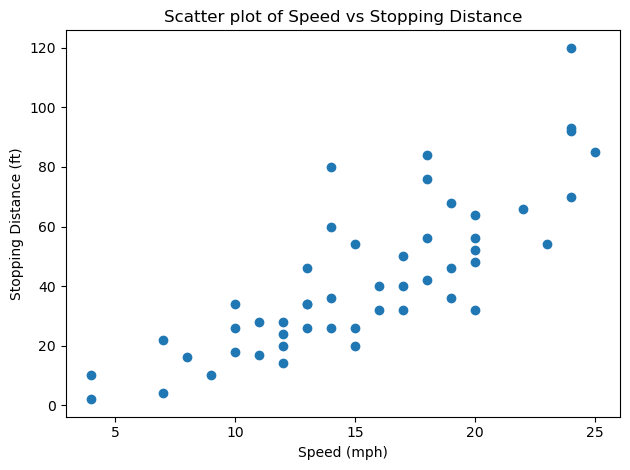

In [8]:
plt.scatter(cars_df["speed"], cars_df["dist"])
plt.title("Scatter plot of Speed vs Stopping Distance") 
plt.xlabel("Speed (mph)")
plt.ylabel("Stopping Distance (ft)")
plt.tight_layout()
plt.title("Scatter plot of Speed vs Stopping Distance")
plt.show()

In [11]:
print(cars_df[["speed", "dist"]].corr())

          speed      dist
speed  1.000000  0.806895
dist   0.806895  1.000000


Positive relationship between speed and stopping distance is expected because as a car's speed increases the distance required to stop also increases due to greater momentum and kinetic energy

(a) Summary statistics for dist:
    mean   = 42.98
    median = 36.00
    std    = 25.77
    min    = 2
    max    = 120


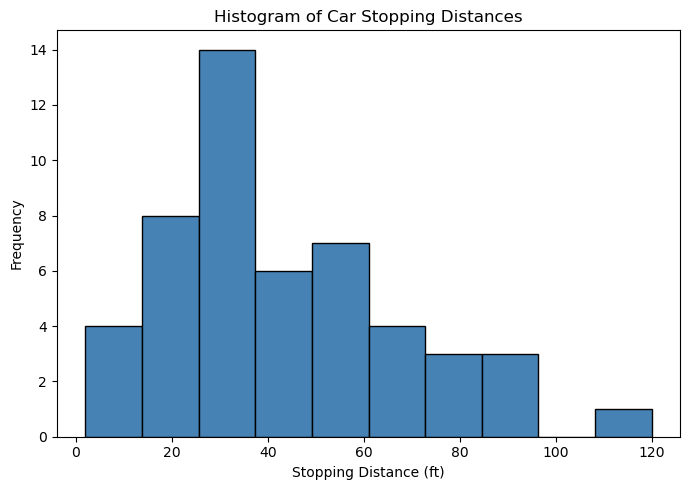

In [7]:

# (a) Summary statistics for dist
dist_mean = cars_df["dist"].mean()
dist_median = cars_df["dist"].median()
dist_std = cars_df["dist"].std()
dist_min = cars_df["dist"].min()
dist_max = cars_df["dist"].max()

print("(a) Summary statistics for dist:")
print(f"    mean   = {dist_mean:.2f}")
print(f"    median = {dist_median:.2f}")
print(f"    std    = {dist_std:.2f}")
print(f"    min    = {dist_min}")
print(f"    max    = {dist_max}")

# (b) Histogram of dist
plt.figure(figsize=(7, 5))
plt.hist(cars_df["dist"], bins=10, color="steelblue", edgecolor="black")
plt.title("Histogram of Car Stopping Distances")
plt.xlabel("Stopping Distance (ft)")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

In [12]:
import statsmodels.api as sm

X = sm.add_constant(cars_df["speed"])   
y = cars_df["dist"]
model = sm.OLS(y, X).fit()
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                   dist   R-squared:                       0.651
Model:                            OLS   Adj. R-squared:                  0.644
Method:                 Least Squares   F-statistic:                     89.57
Date:                Mon, 31 Aug 2026   Prob (F-statistic):           1.49e-12
Time:                        20:22:53   Log-Likelihood:                -206.58
No. Observations:                  50   AIC:                             417.2
Df Residuals:                      48   BIC:                             421.0
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const        -17.5791      6.758     -2.601      0.0

### (c) Interpreting the regression model

The fitted model is `dist ≈ -17.58 + 3.93 × speed`. The slope (≈3.93) is statistically significant (p < 0.001), meaning each additional mph of speed adds about 3.93 ft to stopping distance, on average. The model explains about 65% of the variation in stopping distance ($R^2 \approx 0.65$), confirming the strong positive relationship seen in the scatter plot and correlation.


## Question 4: The Central Limit Theorem (CLT)

### (a) What does the CLT say?

The Central Limit Theorem says that if you repeatedly take random samples of a sufficiently large size ($n$) from *any* population — regardless of the shape of that population's distribution — the distribution of the **sample means** will be approximately **Normally distributed**, centered at the population mean $\mu$, with the spread of sample means shrinking as $n$ grows. In short: individual data can look messy or skewed, but averages of that data behave like a bell curve.

### (b) Conditions under which the CLT generally holds

1. **Random sampling**: Samples must be drawn randomly (and independently) from the population.
2. **Sufficiently large sample size**: $n$ should be large enough (commonly $n \ge 30$ is used as a rule of thumb) — the more skewed the population, the larger $n$ needs to be.
3. **Finite variance**: The population must have a finite mean $\mu$ and finite standard deviation $\sigma$ (no infinite/undefined variance).

### (c) Sampling distribution of mean productivity ($n=100$) from a right-skewed population

Even though the population of individual worker productivity is highly right-skewed, taking many large samples of $n=100$ means the **sampling distribution of the sample mean will be approximately Normal (bell-shaped)** — the CLT "averages out" the skew from the superstar workers because extreme individual values get diluted when averaged over 100 workers.

Its **mean** will equal the population mean: $\mu_{\bar{x}} = \mu$.

Its **standard deviation** (the standard error) will be much smaller than the population's, shrinking with sample size:
$$\sigma_{\bar{x}} = \frac{\sigma}{\sqrt{n}} = \frac{\sigma}{\sqrt{100}} = \frac{\sigma}{10}$$

So the sampling distribution is centered at the same value as the population but is far more tightly clustered and symmetric — a bell curve, not a skewed shape.


## Question 5: Simulating the CLT with the `iris` Sepal.Length variable

In [13]:
# import iris dataset

import seaborn as sns
import matplotlib.pyplot as plt

iris = sns.load_dataset("iris") 

In [15]:
print(iris.head())
print(iris.describe()) 
print(iris.info()) 
print(iris.shape)

   sepal_length  sepal_width  petal_length  petal_width species
0           5.1          3.5           1.4          0.2  setosa
1           4.9          3.0           1.4          0.2  setosa
2           4.7          3.2           1.3          0.2  setosa
3           4.6          3.1           1.5          0.2  setosa
4           5.0          3.6           1.4          0.2  setosa
       sepal_length  sepal_width  petal_length  petal_width
count    150.000000   150.000000    150.000000   150.000000
mean       5.843333     3.057333      3.758000     1.199333
std        0.828066     0.435866      1.765298     0.762238
min        4.300000     2.000000      1.000000     0.100000
25%        5.100000     2.800000      1.600000     0.300000
50%        5.800000     3.000000      4.350000     1.300000
75%        6.400000     3.300000      5.100000     1.800000
max        7.900000     4.400000      6.900000     2.500000
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data

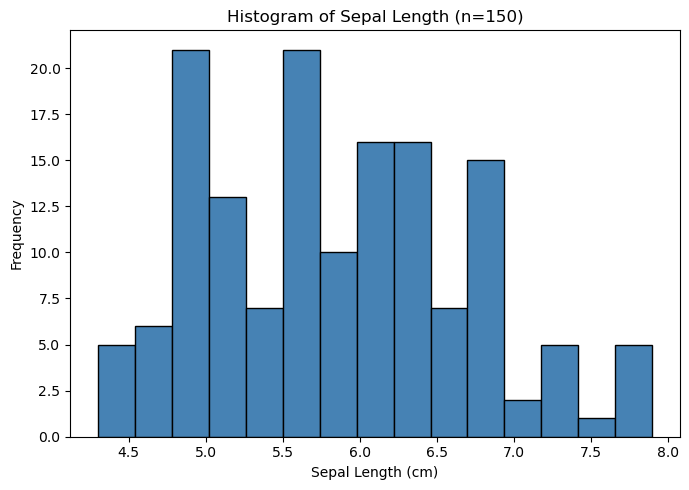

(a) Population mean (mu)    = 5.8433
(a) Population std (sigma)  = 0.8253


In [16]:
# (a) Histogram of Sepal.Length for all 150 flowers, population mean and std
plt.figure(figsize=(7, 5))
plt.hist(iris["sepal_length"], bins=15, color="steelblue", edgecolor="black")
plt.title("Histogram of Sepal Length (n=150)")
plt.xlabel("Sepal Length (cm)")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

pop_mean = iris["sepal_length"].mean()
pop_std = iris["sepal_length"].std(ddof=0)

print(f"(a) Population mean (mu)    = {pop_mean:.4f}")
print(f"(a) Population std (sigma)  = {pop_std:.4f}")


### (a)-(b) Simulation steps

1. Create an empty vector (list) to store sample means.
2. Loop 1,000 times.
3. In each iteration, draw a random sample of size $n=30$ from `sepal_length`.
4. Compute the sample mean and store it.

In [17]:
import numpy as np

rng = np.random.default_rng(42)

n = 30
n_iterations = 1000

# 1. Empty vector to store sample means
sample_means = []

# Loop 1000 times, drawing a sample of size n=30 and storing its mean
for _ in range(n_iterations):
    sample = rng.choice(iris["sepal_length"], size=n, replace=False)
    sample_means.append(sample.mean())

sample_means = np.array(sample_means)
print(f"Collected {len(sample_means)} sample means.")

Collected 1000 sample means.


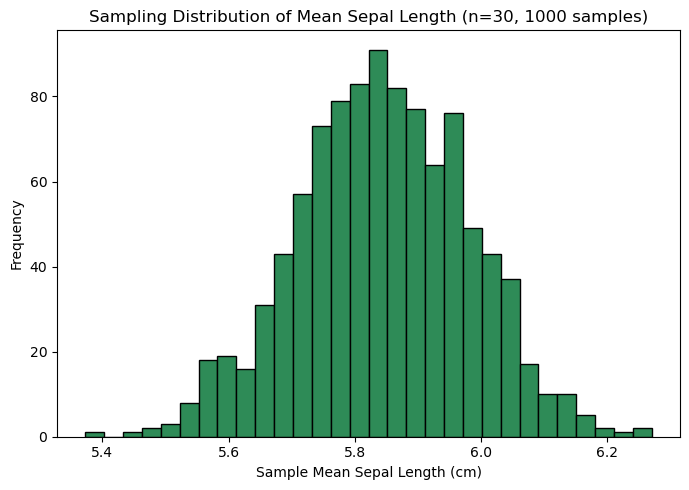

Empirical mean of sample means   = 5.8444   (population mu = 5.8433)
Empirical std of sample means    = 0.1360   (theoretical sigma/sqrt(n) = 0.1507)


In [ ]:
# (c) Histogram of the 1,000 sample means
plt.figure(figsize=(7, 5))
plt.hist(sample_means, bins=30, color="seagreen", edgecolor="black")
plt.title("Sampling Distribution of Mean Sepal Length (n=30, 1000 samples)")
plt.xlabel("Sample Mean Sepal Length (cm)")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

# Empirical mean/std of the sampling distribution
mean_of_means = sample_means.mean() # type: ignore
std_of_means = sample_means.std(ddof=1) # type: ignore

# Theoretical values predicted by the CLT (using population mu/sigma from part a)
theoretical_se = pop_std / np.sqrt(n)

print(f"Empirical mean of sample means   = {mean_of_means:.4f}   (population mu = {pop_mean:.4f})")
print(f"Empirical std of sample means    = {std_of_means:.4f}   (theoretical sigma/sqrt(n) = {theoretical_se:.4f})")


### Discussion

The histogram of the 1,000 sample means is roughly bell-shaped and symmetric, even though individual `sepal_length` values are not perfectly Normal — exactly what the CLT predicts for $n=30$. The empirical mean of the sample means is very close to the population mean $\mu$, and the empirical standard deviation of the sample means closely matches the theoretical standard error $\sigma/\sqrt{n}$. This confirms the CLT: $\mu_{\bar{x}} \approx \mu$ and $\sigma_{\bar{x}} \approx \sigma/\sqrt{n}$, with the sampling distribution far more tightly clustered around the mean than the original population.


## Question 6: Assessing a New Policy 

Given *Normal distribution*:

$$
X\sim N(\mu=70,000,\sigma=18,000)
$$

**z-score**:

$$
z=\frac{x-\mu}{\sigma}
$$

# a Percentage of households with income between $52,000 and $106,000

We want to find:
$$
P(52,000<X<106,000)
$$

### Convert $52,000 to a z-score

$$
z_1=\frac{52,000-70,000}{18,000}
$$

$$
z_1=\frac{-18,000}{18,000}=-1
$$

### Convert $106,000 to a z-score

$$
z_2=\frac{106,000-70,000}{18,000}
$$

$$
z_2=2
$$

$$
P(-1<Z<2)
$$

From the standard normal table:

$$
P(Z<2)=0.9772
$$

$$
P(Z<-1)=0.1587
$$

Therefore:

$$
P(-1<Z<2)=0.9772-0.1587
$$

$$
=0.8185
$$

### Answer:

$$
\boxed{81.85\%}
$$

Approx.: **81.9% of households** have incomes between $52,000 and $106,000.

# (b) Minimum income to be in the top 5%

"Top 5%" means **95% of households are below this income**.

then we need the **95th percentile**:

$$
P(X<x)=0.95
$$

From the standard normal table:

$$
z_{0.95}\approx1.645
$$

Then we can convert the z-score back to the original income:

$$
x=\mu+z\sigma
$$

$$
x=70,000+(1.645)(18,000)
$$

$$
x=70,000+29,610
$$

$$
x=99,610
$$

So a household needs to earn approximately **$99,610 or more** to be in the top 5%.

# (c) Maximum income to qualify for the bottom 20%

"Bottom 20%" means we need the **20th percentile**.

Thus we need to find the z-score for the 20th percentile:

$$
P(X<x)=0.20
$$

Z score table:

$$
z_{0.20}\approx -0.842
$$

Convert this back to income:

$$
x=\mu+z\sigma
$$

$$
x=70,000+(-0.842)(18,000)
$$

$$
x=70,000-15,156
$$

$$
x=54,844
$$

So the maximum income is approximately $54,844 to be in the bottom 20%.

## Final Ans:

| Part    | Calculation             |      Answer |
| ------- | ----------------------- | ----------: |
| **(a)** | \(P(52,000<X<106,000)\) |  **81.85%** |
| **(b)** | 95th percentile         | **$99,610** |
| **(c)** | 20th percentile         | **$54,844** |